# Pipeline analityczny — od pytania do decyzji

**Programowanie w Pythonie II** | Wykład 2

Dziś poznasz cały proces analizy danych — od pytania biznesowego do konkretnej decyzji. Ten schemat będziesz powtarzać przez cały semestr:

```
Pytanie biznesowe → Pozyskanie danych → Poznanie danych → Analiza → Wizualizacja → Decyzja
```

## Pytanie biznesowe
**Który dzień tygodnia przynosi największe napiwki?**

Szef restauracji chce wiedzieć, kiedy zatrudnić więcej kelnerów.

## Krok 1: Pozyskaj dane

Zaczynamy od **importu bibliotek** — to jak otwieranie skrzynki z narzędziami:
- `pandas` — biblioteka do pracy z tabelami danych (jak Excel, ale w Pythonie). Skrót `pd` to konwencja — cały świat Pythona tak pisze
- `matplotlib.pyplot` — biblioteka do tworzenia wykresów. Skrót `plt` — też konwencja

Potem wczytujemy dane z internetu jedną linią. `df` to skrót od **DataFrame** — tak w Pandas nazywa się tabelka z danymi.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv')

## Krok 2: Poznaj dane

Zanim cokolwiek analizujesz — **najpierw zobacz co masz**. To jak otwarcie pudełka i sprawdzenie co jest w środku.

- `.shape` — ile wierszy i kolumn (rozmiar tabelki)
- `.columns` — nazwy kolumn
- `.head()` — pokaż 5 pierwszych wierszy (żebyś widział jak wyglądają dane)

**Uruchom poniższe komórki po kolei (Shift+Enter):**

In [2]:
print(f"Rozmiar: {df.shape[0]} wierszy, {df.shape[1]} kolumn")
print(f"Kolumny: {list(df.columns)}")

Rozmiar: 244 wierszy, 7 kolumn
Kolumny: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


In [3]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Krok 3: Statystyki opisowe

`.describe()` — jedną komendą dostajesz **podsumowanie liczbowe** każdej kolumny:
- **count** — ile wartości (czy czegoś nie brakuje?)
- **mean** — średnia
- **min / max** — zakres danych
- **25%, 50%, 75%** — kwartyle (50% to mediana)

Zauważ — nie napisaliśmy ani jednej pętli. Pandas robi to za nas.

In [4]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## Krok 4: Odpowiedz na pytanie

Teraz odpowiadamy na pytanie szefa: **który dzień przynosi największe napiwki?**

Co robi ten kod:
- `df.groupby('day')` — pogrupuj dane wg dnia tygodnia (jak tabela przestawna w Excelu)
- `['tip'].mean()` — dla każdej grupy policz średni napiwek
- `.sort_values(ascending=False)` — posortuj od największego

In [5]:
wynik = df.groupby('day')['tip'].mean().sort_values(ascending=False)
print(wynik)
print(f"\nOdpowiedź: {wynik.index[0]} — średni napiwek {wynik.iloc[0]:.2f} $")

day
Sun     3.255132
Sat     2.993103
Thur    2.771452
Fri     2.734737
Name: tip, dtype: float64

Odpowiedź: Sun — średni napiwek 3.26 $


## Krok 5: Wizualizacja

Dane w tabelce są dobre dla analityka, ale szef chce **obrazek**. Tworzymy dwa wykresy obok siebie:
- **Lewy:** wykres słupkowy — średni napiwek w każdym dniu
- **Prawy:** scatter plot — każdy punkt to jeden rachunek (oś X = kwota, oś Y = napiwek)

Nie musisz teraz rozumieć każdej linii — na to poświęcimy cały wykład W09 (Matplotlib).

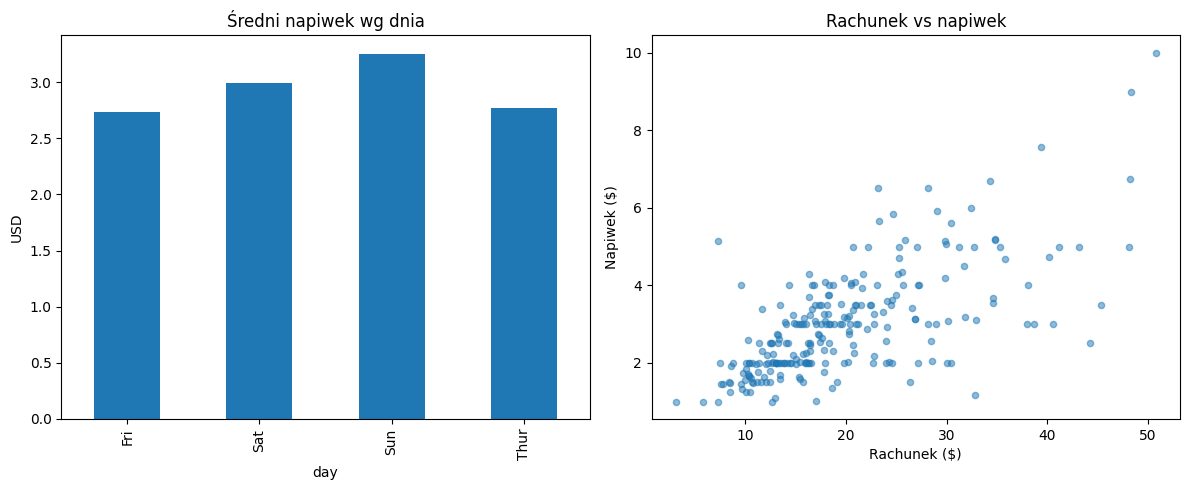

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.groupby('day')['tip'].mean().plot(kind='bar', ax=axes[0], title='Średni napiwek wg dnia')
axes[0].set_ylabel('USD')

df.plot.scatter(x='total_bill', y='tip', alpha=0.5, ax=axes[1], title='Rachunek vs napiwek')
axes[1].set_xlabel('Rachunek ($)')
axes[1].set_ylabel('Napiwek ($)')

plt.tight_layout()
plt.show()

## Krok 6: Decyzja

**Wniosek:** Niedziela przynosi największe napiwki (śr. 3.26 $). Sobota na drugim miejscu.

**Rekomendacja dla szefa:** W weekendy (niedziela, sobota) zatrudnić dodatkowych kelnerów — wyższe napiwki oznaczają większy ruch i większe rachunki.

---

To jest pipeline analityczny: **pytanie → dane → przejrzenie → analiza → wykres → odpowiedź**. Przez następne 13 tygodni będziemy doskonalić każdy z tych kroków.

---

# Typy danych — powtórka z Pythona I

W Pythonie każda wartość ma swój **typ**. Znacie to z semestru 1:

In [7]:
cena = 19.99           # float — liczba zmiennoprzecinkowa
ilosc = 42             # int — liczba całkowita
produkt = "Laptop"     # str — tekst
w_magazynie = True      # bool — prawda/fałsz

print(f"cena: {type(cena).__name__}, ilosc: {type(ilosc).__name__}")
print(f"produkt: {type(produkt).__name__}, w_magazynie: {type(w_magazynie).__name__}")

cena: float, ilosc: int
produkt: str, w_magazynie: bool


### Listy — działają, ale mają ograniczenia

W Pythonie I pracowaliście z listami. Do prostych rzeczy wystarczą:

In [8]:
# Lista cen — ile wynosi średnia?
ceny = [19.99, 29.99, 9.99, 49.99, 14.99]
print(f"Średnia cena: {sum(ceny) / len(ceny):.2f} zł")

Średnia cena: 24.99 zł


Ale co jeśli mamy tabelę danych — jak w Excelu? Lista list szybko staje się brzydka:

In [9]:
# Tabela danych jako lista list — brzydko i łatwo o błąd
zamowienia = [
    ["Laptop", 2999.99, 3],
    ["Mysz", 49.99, 15],
    ["Klawiatura", 149.99, 8],
]

suma = sum(row[1] * row[2] for row in zamowienia)
print(f"Suma zamówień: {suma:.2f} zł")

Suma zamówień: 10949.74 zł


### Problem: brakujące dane

W realnych danych **zawsze** czegoś brakuje. Klient nie podał adresu, sensor nie zapisał pomiaru, ankieta ma puste pola. Listy i słowniki nie mają wbudowanego radzenia sobie z tym:

In [10]:
# Brakujące dane — codzienność analityka
dane_hr = [
    {"imie": "Anna", "pensja": 8500, "dzial": "IT"},
    {"imie": "Jan", "pensja": None, "dzial": "HR"},       # brak pensji!
    {"imie": "Ewa", "pensja": 7200, "dzial": None},       # brak działu!
]

# Jak policzyć średnią pensję pomijając braki? Z listą — trzeba ręcznie:
pensje = [d["pensja"] for d in dane_hr if d["pensja"] is not None]
print(f"Średnia pensja (ręcznie): {sum(pensje) / len(pensje):.0f} zł")

# Pandas robi to jedną metodą — zobaczycie w kolejnych tygodniach

Średnia pensja (ręcznie): 7850 zł


### Typy danych w DataFrame

DataFrame ma swoje typy — Pandas sam rozpoznaje typ każdej kolumny przy wczytywaniu:
- `float64` — kwoty, ceny, wyniki pomiarów (np. rachunek 19.99)
- `int64` — ilości, identyfikatory, liczba sztuk (np. rozmiar stolika 4)
- `object` — tekst, kategorie (np. dzień tygodnia "Sun")

In [11]:
print(df.dtypes)
print(f"\nPamięć: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

total_bill    float64
tip           float64
sex               str
smoker            str
day               str
time              str
size            int64
dtype: object

Pamięć: 56.4 KB


---

# Jupyter Notebook — wasze główne narzędzie

Notebook to nie skrypt — to **narracja z kodem**. Piszesz co robisz, dlaczego, i jakie wnioski wyciągasz. To właśnie odróżnia analityka od programisty — analityk **opowiada historię** danymi.

## Jak utworzyć nowy notebook w VS Code

1. Otwórz **VS Code** w swoim folderze (`code .` w PowerShell)
2. Kliknij w górnym menu: **View → Command Palette** (albo naciśnij `Ctrl+Shift+P`)
   → pojawi się pasek tekstowy u góry ekranu
3. Zacznij wpisywać: `Create New Jupyter Notebook` → gdy zobaczysz tę opcję, kliknij ją
   → otworzy się nowy notebook z jedną pustą komórką
4. Zapisz od razu: `Ctrl+S` → wpisz nazwę, np. `lab02_eksploracja.ipynb`

## Jak wybrać kernel (środowisko Python)

W **prawym górnym rogu** notebooka zobaczysz przycisk **"Select Kernel"** (lub nazwę Pythona):
1. Kliknij go → **Python Environments** → wybierz pozycję z **`.venv`** w nazwie
2. Jeśli nie widzisz `.venv` na liście:
   - Zamknij VS Code
   - W PowerShell przejdź do folderu ze swoim projektem (`cd ~\Desktop\python2-lab`)
   - Aktywuj środowisko: `.venv\Scripts\Activate.ps1`
   - Ponownie wpisz `code .`

## Jak uruchamiać komórki

- Kliknij na komórkę z kodem i naciśnij **Shift+Enter** — komórka się wykona, wynik pojawi się pod nią
- Uruchamiaj komórki **po kolei, od góry do dołu** — każda kolejna korzysta z wyników poprzedniej
- Komórki z tekstem (Markdown) też można "uruchomić" (Shift+Enter) — po prostu się ładnie sformatują

## Dwa typy komórek

| Typ | Do czego | Jak uruchomić |
|-----|----------|---------------|
| **Code** | Kod Pythona — obliczenia, wykresy | `Shift+Enter` — uruchom i przejdź dalej |
| **Markdown** | Tekst, nagłówki, listy, tabele | `Shift+Enter` — sformatuj |

Jak zmienić typ komórki? W lewym górnym rogu komórki zobaczysz napis **"Code"** — kliknij go i wybierz **"Markdown"** (albo naciśnij `Esc` → `M`).

## Skróty klawiszowe

Najpierw naciśnij `Esc` (tryb komend — ramka wokół komórki), potem:

| Skrót | Co robi |
|-------|--------|
| `B` | Dodaj komórkę **p**oniżej (below) |
| `A` | Dodaj komórkę **p**owyżej (above) |
| `M` | Zmień na Markdown |
| `Y` | Zmień na Code |
| `DD` | Usuń komórkę (dwa razy D) |
| `Z` | Cofnij usunięcie |
| `Enter` | Wejdź do edycji komórki |

## Jeśli coś nie działa

| Problem | Co zrobić |
|---------|----------|
| "Select Kernel" — nie ma `.venv` | Zamknij VS Code, aktywuj venv w PowerShell, wpisz `code .` |
| Komórka pokazuje `ModuleNotFoundError` | Zły kernel — kliknij nazwę kernela u góry i wybierz `.venv` |
| Komórka się "kręci" i nie kończy | Kliknij **Stop** (kwadracik ■) obok komórki |

## Pułapka: kolejność uruchamiania komórek

Komórki **można** uruchamiać w dowolnej kolejności — ale to prowadzi do błędów!

Przykład: mamy trzy komórki. Jeśli uruchomisz komórkę B **przed** komórką C, dostaniesz błąd `NameError` — bo `y` jeszcze nie istnieje.

**Zasada:** uruchamiaj komórki **od góry do dołu**. Numer w nawiasie `[3]` obok komórki mówi w jakiej kolejności ją uruchomiłeś.

Gdy się pogubisz → **Restart Kernel and Run All** (w VS Code: przycisk ⟳ na górze notebooka).

---

# Skąd analityk bierze dane?

W pracy dane przychodzą z wielu miejsc:

| Źródło | Przykład | Pandas |
|--------|---------|--------|
| **CSV / Excel** | Eksporty z systemów, raporty | `pd.read_csv()`, `pd.read_excel()` |
| **Bazy danych** | PostgreSQL, MySQL, SQLite | `pd.read_sql()` |
| **API** | Pogoda, giełda, social media | `requests` + `pd.DataFrame()` |
| **JSON** | Logi, konfiguracje, aplikacje | `pd.read_json()` |
| **Scraping** | Dane ze stron WWW | `BeautifulSoup` + Pandas |

Na tym kursie będziemy głównie pracować z CSV — bo to najpopularniejszy format w firmach. Pandas czyta go jedną linią:

```python
df = pd.read_csv('dane.csv')
```

# Dlaczego potrzebujemy NumPy?

Python ma wbudowane listy, ale przy dużych danych (tysiące, miliony wierszy) są **za wolne**. NumPy przechowuje dane w ciągłym bloku pamięci i wykonuje operacje na całej tablicy naraz — zamiast pętli po każdym elemencie.

Poniższy kod porównuje mnożenie miliona liczb — lista vs NumPy:

In [12]:
import numpy as np
import time

lista = list(range(1_000_000))
tablica = np.array(lista)

start = time.perf_counter()
wynik_lista = [x * 2 for x in lista]
czas_lista = time.perf_counter() - start

start = time.perf_counter()
wynik_numpy = tablica * 2
czas_numpy = time.perf_counter() - start

print(f"Lista:  {czas_lista*1000:.1f} ms")
print(f"NumPy:  {czas_numpy*1000:.1f} ms")
print(f"NumPy jest {czas_lista/czas_numpy:.0f}× szybszy!")

Lista:  51.9 ms
NumPy:  7.0 ms
NumPy jest 7× szybszy!


Za tydzień zaczniemy pracę z NumPy — tablice, operacje wektorowe, szybkość. To fundament, na którym stoją Pandas, Matplotlib i cały ekosystem data science.

---

# Mini-ćwiczenie

Odpowiedz na pytania korzystając z datasetu `tips` (zmienna `df` — wczytaliśmy ją na początku):

1. Ile wierszy i kolumn ma ten dataset? → podpowiedź: `df.shape`
2. Jaka jest największa kwota rachunku? → podpowiedź: `df['total_bill'].max()`
3. Ile było rachunków na obiad (Dinner) vs lunch (Lunch)? → podpowiedź: `df['time'].value_counts()`

In [13]:
# Tutaj wpisz swój kod — spróbuj odpowiedzieć na pytania powyżej


**Odpowiedzi:**
1. 244 wiersze, 7 kolumn
2. 50.81 $
3. Dinner: 176, Lunch: 68 — restauracja zarabia głównie na obiadach

---

# Co was czeka na laboratorium

Żeby zacząć pracę na labie, potrzebujecie **3 komendy** w PowerShell:

```powershell
cd ~\Desktop\python2-lab
.venv\Scripts\Activate.ps1
code .
```

Pierwsza — wchodzicie do swojego folderu (tego z L01). Druga — aktywujecie środowisko. Trzecia — otwieracie VS Code. To będzie wasz **rytuał startowy** na każdych zajęciach.

Potem w VS Code stworzycie notebook `lab02_eksploracja.ipynb` i przejdziecie pipeline samodzielnie:

1. Wczytacie ten sam dataset tips
2. Zbadacie go: `head()`, `info()`, `describe()`
3. Odpowiecie na 5 pytań od menedżera restauracji
4. Zrobicie wykres
5. Commitujecie i pushujecie na GitHub

Wszystko macie w instrukcji — krok po kroku. Nie musicie nic pamiętać na pamięć. Ale dzięki temu co widzieliście dziś, będziecie wiedzieć **po co** robicie każdy krok.

---

## Zadanie domowe (nieoceniane)

Wejdź na [kaggle.com](https://www.kaggle.com/datasets) i przejrzyj 3 datasety z kategorii Business. Zastanów się jakie pytania biznesowe można zadać do tych danych.

---

### Złota myśl

> *"Without data, you're just another person with an opinion."*
> — W. Edwards Deming, statystyk i konsultant (rewolucja jakości w Japonii)

**Ciekawostka:** Nazwa **Jupyter** to nie planeta — to skrót od **Ju**lia + **Py**thon + **R** — trzech języków, z którymi notebook współpracuje.